# CSV sorting and covariance analysis

Load a CSV, inspect its columns, sort rows by a chosen column, and calculate/visualize covariance for selected numeric columns. Update the settings in the next cell before running the analysis.


In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings: edit these for your file ---
CSV_PATH = Path(r"D:\Vipin\projects\leaf_coverage_detector\experiments\9.3.coatnet_2_rw_224_experimentation\data\20crop200samples_leaf_coverage_data\2.test\test\TestParametericClustering\parameter_clusters\2026-10-07T05-55_export.csv")  # e.g. Path(r"D:/data/measurements.csv")
SORT_COLUMN = "leaf_coverage_percent"
SORT_ASCENDING = True  # False sorts largest to smallest
COVARIANCE_COLUMNS = [ "leaf_coverage_percent", "masked_laplacian_variance"
, "masked_tenengrad"
, "masked_brenner"
, "masked_fft_high_frequency_ratio"
, "masked_edge_density"
, "masked_brightness_mean"
, "masked_brightness_std"
, "masked_dark_clip_percent"
, "masked_bright_clip_percent"
, "masked_saturation_mean"]  # None = all numeric columns; or e.g. ["height", "width"]
SAVE_SORTED_CSV = False
SORTED_CSV_PATH = CSV_PATH.with_name(f"{CSV_PATH.stem}_sorted.csv")


In [8]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH.resolve()} — update CSV_PATH in the settings cell.")

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns from {CSV_PATH}")
display(df.head())
print("\nColumns and data types:")
display(df.dtypes.rename("dtype").to_frame())


Loaded 102 rows and 69 columns from D:\Vipin\projects\leaf_coverage_detector\experiments\9.3.coatnet_2_rw_224_experimentation\data\20crop200samples_leaf_coverage_data\2.test\test\TestParametericClustering\parameter_clusters\2026-10-07T05-55_export.csv


,image,image_width,image_height,image_area_pixels,leaf_area_pixels,leaf_coverage_percent,leaf_bbox_width_pixels,leaf_bbox_height_pixels,leaf_bbox_area_pixels,leaf_bbox_width_percent,...,cluster_masked_laplacian_variance,cluster_masked_tenengrad,cluster_masked_brenner,cluster_masked_fft_high_frequency_ratio,cluster_masked_edge_density,cluster_masked_brightness_mean,cluster_masked_brightness_std,cluster_masked_dark_clip_percent,cluster_masked_bright_clip_percent,cluster_masked_saturation_mean
0,D:\Vipin\projects\leaf_coverage_detector\exper...,1440,1080,1555200,0,0.0,0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,D:\Vipin\projects\leaf_coverage_detector\exper...,608,1080,656640,0,0.0,0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,D:\Vipin\projects\leaf_coverage_detector\exper...,810,1080,874800,0,0.0,0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,D:\Vipin\projects\leaf_coverage_detector\exper...,810,1080,874800,0,0.0,0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,D:\Vipin\projects\leaf_coverage_detector\exper...,810,1080,874800,0,0.0,0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0



Columns and data types:


,dtype
image,str
image_width,int64
image_height,int64
image_area_pixels,int64
leaf_area_pixels,int64
...,...
cluster_masked_brightness_mean,int64
cluster_masked_brightness_std,int64
cluster_masked_dark_clip_percent,int64
cluster_masked_bright_clip_percent,int64


In [9]:
if SORT_COLUMN not in df.columns:
    raise KeyError(f"SORT_COLUMN={SORT_COLUMN!r} is not in the CSV. Available columns: {df.columns.tolist()}")

sorted_df = df.sort_values(
    by=SORT_COLUMN, ascending=SORT_ASCENDING, na_position="last"
).reset_index(drop=True)
display(sorted_df.head(20))

if SAVE_SORTED_CSV:
    sorted_df.to_csv(SORTED_CSV_PATH, index=False)
    print(f"Saved sorted data to {SORTED_CSV_PATH.resolve()}")


,image,image_width,image_height,image_area_pixels,leaf_area_pixels,leaf_coverage_percent,leaf_bbox_width_pixels,leaf_bbox_height_pixels,leaf_bbox_area_pixels,leaf_bbox_width_percent,...,cluster_masked_laplacian_variance,cluster_masked_tenengrad,cluster_masked_brenner,cluster_masked_fft_high_frequency_ratio,cluster_masked_edge_density,cluster_masked_brightness_mean,cluster_masked_brightness_std,cluster_masked_dark_clip_percent,cluster_masked_bright_clip_percent,cluster_masked_saturation_mean
0,D:\Vipin\projects\leaf_coverage_detector\exper...,1440,1080,1555200,0,0.000000,0,0,0,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,D:\Vipin\projects\leaf_coverage_detector\exper...,608,1080,656640,0,0.000000,0,0,0,0.000000,...,0,0,0,0,0,0,0,0,0,0
2,D:\Vipin\projects\leaf_coverage_detector\exper...,810,1080,874800,0,0.000000,0,0,0,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,D:\Vipin\projects\leaf_coverage_detector\exper...,810,1080,874800,0,0.000000,0,0,0,0.000000,...,0,0,0,0,0,0,0,0,0,0
4,D:\Vipin\projects\leaf_coverage_detector\exper...,810,1080,874800,0,0.000000,0,0,0,0.000000,...,0,0,0,0,0,0,0,0,0,0
5,D:\Vipin\projects\leaf_coverage_detector\exper...,1440,1080,1555200,0,0.000000,0,0,0,0.000000,...,0,0,0,0,0,0,0,0,0,0
6,D:\Vipin\projects\leaf_coverage_detector\exper...,1440,1080,1555200,0,0.000000,0,0,0,0.000000,...,0,0,0,0,0,0,0,0,0,0
7,D:\Vipin\projects\leaf_coverage_detector\exper...,810,1080,874800,0,0.000000,0,0,0,0.000000,...,0,0,0,0,0,0,0,0,0,0
8,D:\Vipin\projects\leaf_coverage_detector\exper...,1440,1080,1555200,0,0.000000,0,0,0,0.000000,...,0,0,0,0,0,0,0,0,0,0
9,D:\Vipin\projects\leaf_coverage_detector\exper...,810,1080,874800,0,0.000000,0,0,0,0.000000,...,0,0,0,0,0,0,0,0,0,0


In [10]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
if COVARIANCE_COLUMNS is None:
    covariance_columns = numeric_columns
else:
    missing = [column for column in COVARIANCE_COLUMNS if column not in df.columns]
    if missing:
        raise KeyError(f"Covariance columns not found: {missing}")
    non_numeric = [column for column in COVARIANCE_COLUMNS if column not in numeric_columns]
    if non_numeric:
        raise TypeError(f"Covariance requires numeric columns. Non-numeric: {non_numeric}")
    covariance_columns = COVARIANCE_COLUMNS

if len(covariance_columns) < 2:
    raise ValueError(f"Choose at least two numeric columns to compare. Numeric columns: {numeric_columns}")

covariance = df[covariance_columns].cov()
display(covariance.style.format("{:.4g}").background_gradient(cmap="coolwarm", axis=None))
print("Covariance depends on the units and scale of each column. Use correlation for a scale-free comparison.")


,leaf_coverage_percent,masked_laplacian_variance,masked_tenengrad,masked_brenner,masked_fft_high_frequency_ratio,masked_edge_density,masked_brightness_mean,masked_brightness_std,masked_dark_clip_percent,masked_bright_clip_percent,masked_saturation_mean
leaf_coverage_percent,824.2,0.0007056,0.2383,0.009419,-0.3307,1.797,836.1,247.2,0.003087,0.6314,4.037
masked_laplacian_variance,0.0007056,0.00111,0.002246,0.0001442,0.003651,0.0008571,0.227,0.1481,4.403e-05,0.002221,0.001191
masked_tenengrad,0.2383,0.002246,0.006132,0.0003607,0.00803,0.003182,1.368,0.5281,0.0001818,0.009144,0.004859
masked_brenner,0.009419,0.0001442,0.0003607,2.196e-05,0.0005072,0.0001683,0.06545,0.02863,7.928e-06,0.0004909,0.0002602
masked_fft_high_frequency_ratio,-0.3307,0.003651,0.00803,0.0005072,0.02051,0.004549,1.892,0.162,0.000393,0.002738,0.008686
masked_edge_density,1.797,0.0008571,0.003182,0.0001683,0.004549,0.008765,4.767,1.061,9.633e-05,0.004666,0.01524
masked_brightness_mean,836.1,0.227,1.368,0.06545,1.892,4.767,2994,573.3,-0.003796,3.017,7.296
masked_brightness_std,247.2,0.1481,0.5281,0.02863,0.162,1.061,573.3,199.9,0.002385,1.305,1.58
masked_dark_clip_percent,0.003087,4.403e-05,0.0001818,7.928e-06,0.000393,9.633e-05,-0.003796,0.002385,0.0002213,8.425e-05,-7.05e-05
masked_bright_clip_percent,0.6314,0.002221,0.009144,0.0004909,0.002738,0.004666,3.017,1.305,8.425e-05,0.09222,0.0007927


Covariance depends on the units and scale of each column. Use correlation for a scale-free comparison.


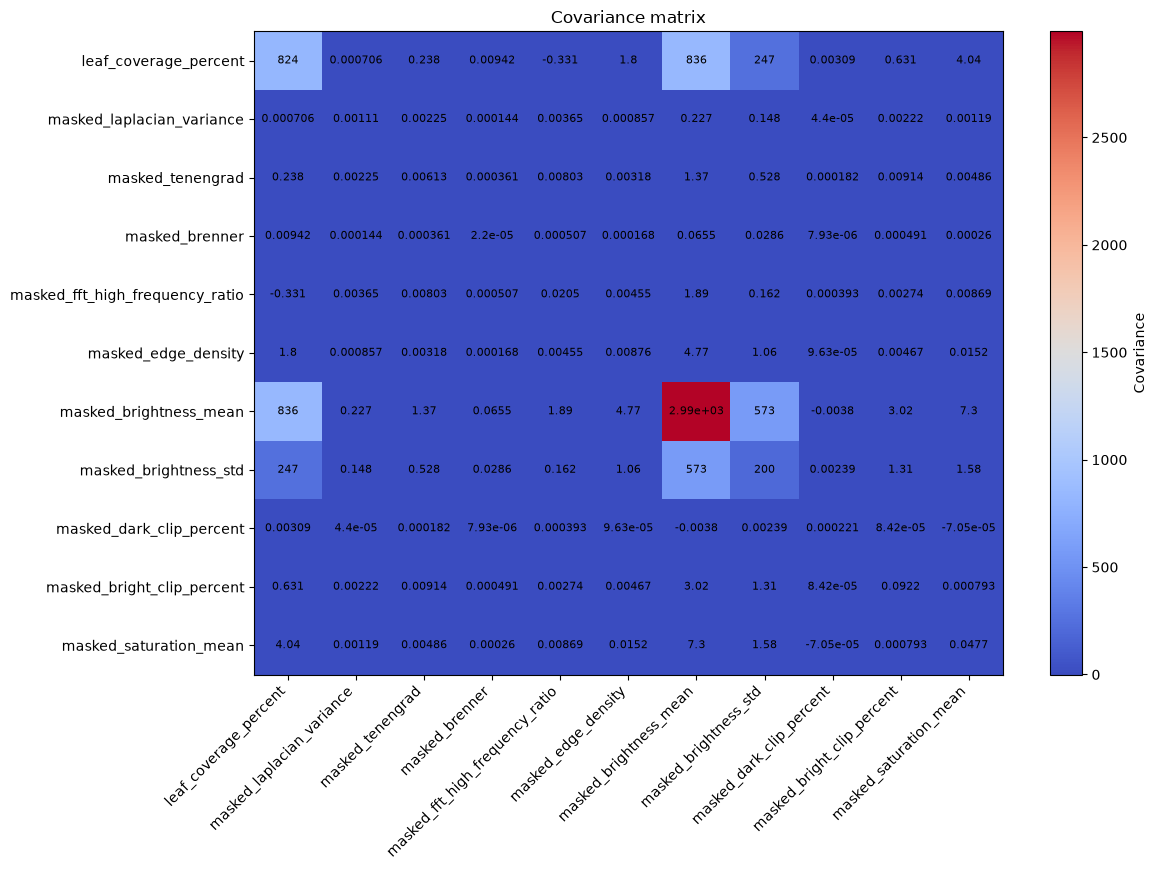

In [11]:
fig, ax = plt.subplots(figsize=(max(6, 1.1 * len(covariance_columns)), max(4, 0.8 * len(covariance_columns))))
image = ax.imshow(covariance, cmap="coolwarm", aspect="auto")
ax.set_xticks(range(len(covariance_columns)), covariance_columns, rotation=45, ha="right")
ax.set_yticks(range(len(covariance_columns)), covariance_columns)
ax.set_title("Covariance matrix")
for row in range(len(covariance_columns)):
    for col in range(len(covariance_columns)):
        ax.text(col, row, f"{covariance.iloc[row, col]:.3g}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Covariance")
fig.tight_layout()
plt.show()


## Optional: correlation

Correlation is the normalized covariance and is often easier to compare across columns with different units. Values range from -1 to 1.


In [12]:
correlation = df[covariance_columns].corr()
display(correlation.style.format("{:.3f}").background_gradient(cmap="coolwarm", vmin=-1, vmax=1))


,leaf_coverage_percent,masked_laplacian_variance,masked_tenengrad,masked_brenner,masked_fft_high_frequency_ratio,masked_edge_density,masked_brightness_mean,masked_brightness_std,masked_dark_clip_percent,masked_bright_clip_percent,masked_saturation_mean
leaf_coverage_percent,1.000,0.001,0.106,0.070,-0.080,0.668,0.532,0.609,0.007,0.072,0.644
masked_laplacian_variance,0.001,1.000,0.861,0.924,0.765,0.275,0.124,0.314,0.089,0.220,0.164
masked_tenengrad,0.106,0.861,1.000,0.983,0.716,0.434,0.319,0.477,0.156,0.385,0.284
masked_brenner,0.070,0.924,0.983,1.000,0.756,0.383,0.255,0.432,0.114,0.345,0.254
masked_fft_high_frequency_ratio,-0.080,0.765,0.716,0.756,1.000,0.339,0.241,0.080,0.184,0.063,0.278
masked_edge_density,0.668,0.275,0.434,0.383,0.339,1.000,0.931,0.802,0.069,0.164,0.745
masked_brightness_mean,0.532,0.124,0.319,0.255,0.241,0.931,1.000,0.741,-0.005,0.182,0.611
masked_brightness_std,0.609,0.314,0.477,0.432,0.080,0.802,0.741,1.000,0.011,0.304,0.512
masked_dark_clip_percent,0.007,0.089,0.156,0.114,0.184,0.069,-0.005,0.011,1.000,0.019,-0.022
masked_bright_clip_percent,0.072,0.220,0.385,0.345,0.063,0.164,0.182,0.304,0.019,1.000,0.012
